# Clasificación de Sentimientos con Encoders: MDSD Dataset

## Objetivo
Comparar el desempeño de dos modelos BERT pre-entrenados (**bert-base-uncased** y **distilbert-base-uncased**) para clasificación binaria de sentimientos en el dataset **MDSD (Multi-Domain Sentiment Dataset)**.

### Dataset
- **MDSD**: Reseñas de productos de Amazon
- **Clases**: 2 (positive, negative)
- **Formato**: Bag-of-words con frecuencias

---

## 1. Configuración del Ambiente

Importamos las librerías necesarias y verificamos la disponibilidad de GPU.

In [1]:
import os
import time
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Configurar semilla para reproducibilidad
SEED = 29
torch.manual_seed(SEED)
np.random.seed(SEED)

# Verificar GPU disponible
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

/home/estudiante/tldr-uniandes/encoders-vs-decoders-classification/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.0+cu128
CUDA disponible: True
GPU: NVIDIA A40-24C
Memoria GPU: 23.78 GB


### 🔍 Monitoreo de GPU

Antes de entrenar, revisemos el estado actual de la GPU para detectar procesos que puedan estar ocupando memoria.

In [2]:
import subprocess
import torch

def check_gpu_usage():
    """Revisa el uso actual de GPU con nvidia-smi"""
    print("="*80)
    print("🔍 ESTADO ACTUAL DE LA GPU")
    print("="*80)
    
    try:
        # Información básica de GPU
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        print(result.stdout)
        
        print("\n" + "="*80)
        print("📊 PROCESOS USANDO GPU")
        print("="*80)
        
        # Procesos específicos en GPU
        result = subprocess.run(
            ['nvidia-smi', '--query-compute-apps=pid,process_name,used_memory', '--format=csv'],
            capture_output=True, text=True
        )
        print(result.stdout)
        
    except Exception as e:
        print(f"❌ Error al obtener info de GPU: {e}")
    
    # Información de PyTorch
    print("\n" + "="*80)
    print("🔥 MEMORIA GPU EN PYTORCH")
    print("="*80)
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            print(f"\nGPU {i}: {torch.cuda.get_device_name(i)}")
            print(f"  Memoria Asignada:  {torch.cuda.memory_allocated(i) / 1024**3:.2f} GB")
            print(f"  Memoria Reservada: {torch.cuda.memory_reserved(i) / 1024**3:.2f} GB")
            print(f"  Memoria Total:     {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")
    else:
        print("❌ CUDA no disponible")

# Ejecutar verificación
check_gpu_usage()

🔍 ESTADO ACTUAL DE LA GPU
Tue Nov 11 17:19:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.90.07              Driver Version: 550.90.07      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40-24C                 On  |   00000000:06:10.0 Off |                  N/A |
| N/A   N/A    P0             N/A /  N/A  |    7285MiB /  24576MiB |     48%      Default |
|                                         |                        |                  N/A |
+---------------------

In [3]:
# Liberar memoria GPU si hay modelos cargados anteriormente
import gc
import torch

print("🧹 Liberando memoria GPU...")

# Limpiar cache de PyTorch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("✓ Cache de CUDA vaciado")

# Ejecutar garbage collector
gc.collect()
print("✓ Garbage collector ejecutado")

# Verificar memoria después de limpiar
print("\n📊 Memoria GPU después de limpiar:")
if torch.cuda.is_available():
    print(f"  Asignada:  {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"  Reservada: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
    print(f"  Libre:     {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1024**3:.2f} GB")
else:
    print("❌ CUDA no disponible")

🧹 Liberando memoria GPU...
✓ Cache de CUDA vaciado
✓ Garbage collector ejecutado

📊 Memoria GPU después de limpiar:
  Asignada:  0.00 GB
  Reservada: 0.00 GB
  Libre:     23.78 GB


In [4]:
# ✅ Test rápido: verificar que el kernel funciona
import torch
print("✅ Kernel funcionando correctamente")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Memoria GPU libre: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1024**3:.2f} GB")
print("\n🎯 Si ves este mensaje, el kernel está OK y puedes continuar con el entrenamiento")

✅ Kernel funcionando correctamente
PyTorch: 2.9.0+cu128
CUDA disponible: True
Memoria GPU libre: 23.78 GB

🎯 Si ves este mensaje, el kernel está OK y puedes continuar con el entrenamiento


---

## 2. Carga del Dataset MDSD

El dataset MDSD contiene reseñas de productos en formato bag-of-words. Cada línea representa una reseña con:
- Palabras y sus frecuencias (formato: `palabra:frecuencia`)
- Etiqueta al final: `#label#:positive` o `#label#:negative`

Cargaremos y procesaremos los datos para convertirlos en texto plano.

In [5]:
def parse_mdsd_line(line):
    """
    Parsea una línea del dataset MDSD en formato bag-of-words.
    
    Formato: palabra1:freq1 palabra2:freq2 ... #label#:positive/negative
    
    Args:
        line: String con la línea a parsear
        
    Returns:
        Tupla (texto_reconstruido, label)
    """
    # Extraer la etiqueta
    if '#label#:positive' in line:
        label = 'positive'
        line = line.replace('#label#:positive', '').strip()
    elif '#label#:negative' in line:
        label = 'negative'
        line = line.replace('#label#:negative', '').strip()
    else:
        return None, None
    
    # Parsear palabras y frecuencias
    words = []
    tokens = line.split()
    
    for token in tokens:
        if ':' in token:
            word, freq = token.rsplit(':', 1)
            try:
                freq = int(freq)
                # Reconstruir la palabra reemplazando guiones bajos por espacios
                word_clean = word.replace('_', ' ')
                # Repetir la palabra según su frecuencia
                words.extend([word_clean] * freq)
            except ValueError:
                # Si no se puede convertir a int, es parte del texto
                words.append(token)
    
    # Unir las palabras en un texto
    text = ' '.join(words)
    
    return text, label

def load_mdsd_file(filepath):
    """
    Carga un archivo MDSD y lo convierte a DataFrame.
    
    Args:
        filepath: Ruta al archivo
        
    Returns:
        DataFrame con columnas ['text', 'label']
    """
    data = []
    
    print(f"Cargando {filepath}...")
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            text, label = parse_mdsd_line(line.strip())
            if text and label:
                data.append({
                    'text': text,
                    'label': label
                })
            
            if (i + 1) % 1000 == 0:
                print(f"  Procesadas {i + 1} líneas...")
    
    df = pd.DataFrame(data)
    print(f"✓ Cargadas {len(df)} reseñas")
    
    return df

print("✓ Funciones de carga creadas")

✓ Funciones de carga creadas


In [6]:
# Cargar reseñas de diferentes dominios para formar el conjunto de train+val
# Usaremos todos los dominios disponibles en processed_acl

domains = ['books', 'dvd', 'electronics', 'kitchen']
all_train_val_data = []

for domain in domains:
    # Cargar negativas
    neg_path = f'../mdsd/processed_acl/processed_acl/{domain}/negative.review'
    if os.path.exists(neg_path):
        neg_df = load_mdsd_file(neg_path)
        neg_df['domain'] = domain
        all_train_val_data.append(neg_df)
    
    # Cargar positivas
    pos_path = f'../mdsd/processed_acl/processed_acl/{domain}/positive.review'
    if os.path.exists(pos_path):
        pos_df = load_mdsd_file(pos_path)
        pos_df['domain'] = domain
        all_train_val_data.append(pos_df)

# Combinar todos los datos de train+val
train_val_df = pd.concat(all_train_val_data, ignore_index=True)

# Mapear etiquetas a números
label_to_id = {'negative': 0, 'positive': 1}
train_val_df['label_id'] = train_val_df['label'].map(label_to_id)

print(f"\n{'='*60}")
print("DATOS DE ENTRENAMIENTO + VALIDACIÓN")
print(f"{'='*60}")
print(f"Total de reseñas: {len(train_val_df)}")
print(f"\nDistribución por etiqueta:")
print(train_val_df['label'].value_counts())
print(f"\nDistribución por dominio:")
print(train_val_df['domain'].value_counts())
print(f"\nEjemplo de reseña:")
print(f"Dominio: {train_val_df.iloc[0]['domain']}")
print(f"Label: {train_val_df.iloc[0]['label']}")
print(f"Texto (primeros 200 caracteres):\n{train_val_df.iloc[0]['text'][:200]}")

Cargando ../mdsd/processed_acl/processed_acl/books/negative.review...
  Procesadas 1000 líneas...
✓ Cargadas 1000 reseñas
Cargando ../mdsd/processed_acl/processed_acl/books/positive.review...
  Procesadas 1000 líneas...
✓ Cargadas 1000 reseñas
Cargando ../mdsd/processed_acl/processed_acl/dvd/negative.review...
  Procesadas 1000 líneas...
✓ Cargadas 1000 reseñas
Cargando ../mdsd/processed_acl/processed_acl/dvd/positive.review...
  Procesadas 1000 líneas...
✓ Cargadas 1000 reseñas
Cargando ../mdsd/processed_acl/processed_acl/dvd/negative.review...
  Procesadas 1000 líneas...
✓ Cargadas 1000 reseñas
Cargando ../mdsd/processed_acl/processed_acl/dvd/positive.review...
  Procesadas 1000 líneas...
✓ Cargadas 1000 reseñas
Cargando ../mdsd/processed_acl/processed_acl/electronics/negative.review...
  Procesadas 1000 líneas...
✓ Cargadas 1000 reseñas
Cargando ../mdsd/processed_acl/processed_acl/electronics/positive.review...
  Procesadas 1000 líneas...
✓ Cargadas 1000 reseñas
Cargando ../mdsd/pro

In [7]:
# Cargar conjunto de test (unlabeled.review)
# Nota: Este archivo contiene reseñas sin etiquetar explícita en el nombre,
# pero según el formato bag-of-words deberían tener etiquetas

test_df = load_mdsd_file('../mdsd/unlabeled.review')
test_df['label_id'] = test_df['label'].map(label_to_id)

print(f"\n{'='*60}")
print("DATOS DE TEST (unlabeled.review)")
print(f"{'='*60}")
print(f"Total de reseñas: {len(test_df)}")
print(f"\nDistribución por etiqueta:")
print(test_df['label'].value_counts())
print(f"\nEjemplo de reseña de test:")
print(f"Label: {test_df.iloc[0]['label']}")
print(f"Texto (primeros 200 caracteres):\n{test_df.iloc[0]['text'][:200]}")

Cargando ../mdsd/unlabeled.review...
  Procesadas 1000 líneas...
  Procesadas 1000 líneas...
  Procesadas 2000 líneas...
  Procesadas 2000 líneas...
  Procesadas 3000 líneas...
  Procesadas 3000 líneas...
  Procesadas 4000 líneas...
✓ Cargadas 4465 reseñas

DATOS DE TEST (unlabeled.review)
Total de reseñas: 4465

Distribución por etiqueta:
label
positive    2264
negative    2201
Name: count, dtype: int64

Ejemplo de reseña de test:
Label: negative
Texto (primeros 200 caracteres):
is such feel pages if his kooky to kill its welcome and he our "hero" who apparently out its repeating that ranges a weakness placed the he hadn't a cast florida is because long also has he has welcom
  Procesadas 4000 líneas...
✓ Cargadas 4465 reseñas

DATOS DE TEST (unlabeled.review)
Total de reseñas: 4465

Distribución por etiqueta:
label
positive    2264
negative    2201
Name: count, dtype: int64

Ejemplo de reseña de test:
Label: negative
Texto (primeros 200 caracteres):
is such feel pages if his kooky to

### 2.1. Split Train/Validation

Dividiremos el conjunto de `train_val_df` en:
- **Train**: 90% de los datos
- **Validation**: 10% de los datos

El conjunto de **Test** ya está definido (`unlabeled.review`).

In [8]:
# Split train/validation estratificado por etiqueta
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.10,  # 10% para validación
    stratify=train_val_df['label_id'],  # Mantener proporción de clases
    random_state=SEED
)

# Resetear índices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"{'='*60}")
print("SPLITS FINALES")
print(f"{'='*60}")
print(f"\nTrain:      {len(train_df):,} reseñas ({len(train_df)/len(train_val_df)*100:.1f}%)")
print(f"Validation: {len(val_df):,} reseñas ({len(val_df)/len(train_val_df)*100:.1f}%)")
print(f"Test:       {len(test_df):,} reseñas")
print(f"Total:      {len(train_df) + len(val_df) + len(test_df):,} reseñas")

print(f"\n{'='*60}")
print("DISTRIBUCIÓN DE ETIQUETAS POR SPLIT")
print(f"{'='*60}")

print(f"\nTrain:")
train_counts = train_df['label'].value_counts()
for label, count in train_counts.items():
    print(f"  {label:10s}: {count:,} ({count/len(train_df)*100:.1f}%)")

print(f"\nValidation:")
val_counts = val_df['label'].value_counts()
for label, count in val_counts.items():
    print(f"  {label:10s}: {count:,} ({count/len(val_df)*100:.1f}%)")

print(f"\nTest:")
test_counts = test_df['label'].value_counts()
for label, count in test_counts.items():
    print(f"  {label:10s}: {count:,} ({count/len(test_df)*100:.1f}%)")

print(f"{'='*60}")

SPLITS FINALES

Train:      7,200 reseñas (90.0%)
Validation: 800 reseñas (10.0%)
Test:       4,465 reseñas
Total:      12,465 reseñas

DISTRIBUCIÓN DE ETIQUETAS POR SPLIT

Train:
  positive  : 3,600 (50.0%)
  negative  : 3,600 (50.0%)

Validation:
  positive  : 400 (50.0%)
  negative  : 400 (50.0%)

Test:
  positive  : 2,264 (50.7%)
  negative  : 2,201 (49.3%)


### 2.2. Guardar Splits para Reproducibilidad

Para asegurar que los resultados sean comparables, podemos guardar los splits en archivos CSV.

In [9]:
# Crear directorio para guardar los splits
splits_dir = 'data_splits_mdsd'
os.makedirs(splits_dir, exist_ok=True)

# Guardar cada split en CSV
train_df.to_csv(f'{splits_dir}/train.csv', index=False)
val_df.to_csv(f'{splits_dir}/val.csv', index=False)
test_df.to_csv(f'{splits_dir}/test.csv', index=False)

# Guardar también el mapeo de labels
import json
with open(f'{splits_dir}/label_to_id.json', 'w') as f:
    json.dump(label_to_id, f, indent=2)

print(f"✓ Splits guardados en '{splits_dir}/'")
print(f"  - train.csv: {len(train_df):,} reseñas")
print(f"  - val.csv: {len(val_df):,} reseñas")
print(f"  - test.csv: {len(test_df):,} reseñas")
print(f"  - label_to_id.json")

✓ Splits guardados en 'data_splits_mdsd/'
  - train.csv: 7,200 reseñas
  - val.csv: 800 reseñas
  - test.csv: 4,465 reseñas
  - label_to_id.json


---

## 3. Preparación del Dataset para PyTorch

Crearemos un Dataset personalizado compatible con el **Trainer** de Hugging Face.

In [10]:
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    """
    Dataset personalizado para el dataset MDSD (clasificación de sentimientos).
    
    Args:
        texts: Lista de textos (reseñas)
        labels: Lista de etiquetas numéricas (0=negative, 1=positive)
        tokenizer: Tokenizador de Hugging Face
        max_length: Longitud máxima de tokens
    """
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenizar el texto
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("✓ Clase SentimentDataset creada correctamente")

✓ Clase SentimentDataset creada correctamente


---

## 4. Fine-tuning con Hugging Face Trainer

Usaremos el **Trainer** de Hugging Face que proporciona:
- ✅ Early stopping automático
- ✅ Checkpointing en cada época
- ✅ Guardado del mejor modelo
- ✅ Logging y métricas
- ✅ Evaluación automática

### 4.1. Configuración de Hiperparámetros

In [15]:
# Hiperparámetros ITERACIÓN FINAL (escape de mínimos locales)
LEARNING_RATE = 3e-6      # Punto óptimo: lo suficientemente alto para escapar, bajo para no overfitear
BATCH_SIZE = 32
MAX_EPOCHS = 100          # Permitir que explore más
MAX_LENGTH = 512
EARLY_STOPPING_PATIENCE = 8   # Paciencia moderada (si no mejora en 4 épocas, para)
WEIGHT_DECAY = 0.15     # Regularización constante

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*60)
print(f"Learning Rate:        {LEARNING_RATE}")
print(f"Batch Size:           {BATCH_SIZE}")
print(f"Max Epochs:           {MAX_EPOCHS}")
print(f"Max Length (tokens):  {MAX_LENGTH}")
print(f"Early Stop Patience:  {EARLY_STOPPING_PATIENCE} épocas")
print(f"Weight Decay:         {WEIGHT_DECAY} (regularización L2)")
print(f"Device:               {device}")
print("="*60)

Learning Rate:        3e-06
Batch Size:           32
Max Epochs:           100
Max Length (tokens):  512
Early Stop Patience:  8 épocas
Weight Decay:         0.15 (regularización L2)
Device:               cuda


### 4.2. Función para calcular métricas

El Trainer necesita una función que compute las métricas durante la evaluación.

In [16]:
def compute_metrics(eval_pred):
    """
    Función para calcular métricas durante la evaluación.
    
    Args:
        eval_pred: Tupla (predictions, labels)
        
    Returns:
        Dict con las métricas calculadas
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calcular métricas
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary', zero_division=0
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✓ Función compute_metrics creada")

✓ Función compute_metrics creada


### 4.3. Entrenamiento de BERT-base-uncased

Configuraremos el **Trainer** con todas las features necesarias:
- **Early Stopping**: Se detiene si no mejora después de N épocas
- **Checkpointing**: Guarda el modelo en cada época
- **Best Model**: Guarda automáticamente el mejor modelo según eval_loss
- **Logging**: Registra todas las métricas

In [17]:
# Cargar tokenizador y modelo BERT-base
print("Cargando bert-base-uncased...")
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,  # Clasificación binaria (positive, negative)
    problem_type="single_label_classification"
)

print(f"✓ Modelo cargado")
print(f"  Parámetros: {sum(p.numel() for p in bert_model.parameters()):,}")

Cargando bert-base-uncased...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo cargado
  Parámetros: 109,483,778


In [18]:
# Crear datasets
print("Creando datasets para BERT...")
bert_train_dataset = SentimentDataset(
    texts=train_df['text'].tolist(),
    labels=train_df['label_id'].tolist(),
    tokenizer=bert_tokenizer,
    max_length=MAX_LENGTH
)

bert_val_dataset = SentimentDataset(
    texts=val_df['text'].tolist(),
    labels=val_df['label_id'].tolist(),
    tokenizer=bert_tokenizer,
    max_length=MAX_LENGTH
)

bert_test_dataset = SentimentDataset(
    texts=test_df['text'].tolist(),
    labels=test_df['label_id'].tolist(),
    tokenizer=bert_tokenizer,
    max_length=MAX_LENGTH
)

print(f"✓ Train dataset: {len(bert_train_dataset):,} ejemplos")
print(f"✓ Val dataset:   {len(bert_val_dataset):,} ejemplos")
print(f"✓ Test dataset:  {len(bert_test_dataset):,} ejemplos")

Creando datasets para BERT...
✓ Train dataset: 7,200 ejemplos
✓ Val dataset:   800 ejemplos
✓ Test dataset:  4,465 ejemplos


In [19]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

# Configurar TrainingArguments (aquí está TODA la configuración)
training_args = TrainingArguments(
    # Directorio de salida
    output_dir='./results_bert_mdsd',
    
    # Entrenamiento
    num_train_epochs=MAX_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    
    # Evaluación y guardado
    eval_strategy="epoch",              # Evaluar al final de cada época
    save_strategy="epoch",              # Guardar checkpoint cada época
    save_total_limit=3,                 # Mantener solo los 3 mejores checkpoints
    load_best_model_at_end=True,       # Cargar el mejor modelo al final
    metric_for_best_model="eval_loss", # Usar eval_loss para determinar el mejor
    greater_is_better=False,            # False porque queremos minimizar loss
    
    # Learning Rate Scheduler (CLAVE para escapar de mínimos locales)
    lr_scheduler_type="linear",         # Reduce LR linealmente durante el entrenamiento
    warmup_steps=0,                     # Sin warmup
    
    # Logging
    logging_dir='./logs_bert_mdsd',
    logging_strategy="epoch",
    logging_steps=100,
    report_to="none",  # Puedes cambiar a "tensorboard" o "wandb" si quieres
    
    # Reproducibilidad
    seed=SEED,
    
    # Performance
    fp16=torch.cuda.is_available(),  # Mixed precision si hay GPU
)

# Crear el Trainer
bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )
    ]
)

print("="*60)
print("TRAINER CONFIGURADO PARA BERT")
print("="*60)
print(f"✓ Early Stopping: patience={EARLY_STOPPING_PATIENCE}")
print(f"✓ Checkpointing: cada época en './results_bert_mdsd'")
print(f"✓ Mejor modelo: se guarda automáticamente")
print(f"✓ Métricas: accuracy, precision, recall, f1")
print("="*60)

TRAINER CONFIGURADO PARA BERT
✓ Early Stopping: patience=8
✓ Checkpointing: cada época en './results_bert_mdsd'
✓ Mejor modelo: se guarda automáticamente
✓ Métricas: accuracy, precision, recall, f1


In [20]:
# ¡Entrenar! (Solo esta línea y ya está 🚀)
print("\n🚀 Iniciando entrenamiento de BERT...\n")
bert_trainer.train()

print("\n✅ Entrenamiento completado!")
print(f"📁 Mejor modelo guardado en: {training_args.output_dir}")


🚀 Iniciando entrenamiento de BERT...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.538900,0.411819,0.823750,0.765914,0.932500,0.841037
2,0.351000,0.341819,0.860000,0.854680,0.867500,0.861042
3,0.301800,0.341240,0.861250,0.904762,0.807500,0.853369
4,0.267200,0.314929,0.878750,0.877805,0.880000,0.878901
5,0.229400,0.353868,0.865000,0.910112,0.810000,0.857143
6,0.194800,0.316665,0.888750,0.878345,0.902500,0.890259
7,0.170700,0.342185,0.891250,0.892231,0.890000,0.891114
8,0.147000,0.356535,0.883750,0.890585,0.875000,0.882724
9,0.118300,0.389516,0.888750,0.878345,0.902500,0.890259
10,0.096200,0.451696,0.876250,0.897098,0.850000,0.872914



✅ Entrenamiento completado!
📁 Mejor modelo guardado en: ./results_bert_mdsd


### 4.4. Entrenamiento de DistilBERT-base-uncased

DistilBERT es una versión destilada de BERT con:
- **40% menos parámetros** (66M vs 110M)
- **60% más rápido** en inferencia
- **97% del rendimiento** de BERT

In [21]:
# Cargar tokenizador y modelo DistilBERT
print("Cargando distilbert-base-uncased...")
distilbert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
    problem_type="single_label_classification"
)

print(f"✓ Modelo cargado")
print(f"  Parámetros: {sum(p.numel() for p in distilbert_model.parameters()):,}")

# Crear datasets para DistilBERT
print("\nCreando datasets para DistilBERT...")
distilbert_train_dataset = SentimentDataset(
    texts=train_df['text'].tolist(),
    labels=train_df['label_id'].tolist(),
    tokenizer=distilbert_tokenizer,
    max_length=MAX_LENGTH
)

distilbert_val_dataset = SentimentDataset(
    texts=val_df['text'].tolist(),
    labels=val_df['label_id'].tolist(),
    tokenizer=distilbert_tokenizer,
    max_length=MAX_LENGTH
)

distilbert_test_dataset = SentimentDataset(
    texts=test_df['text'].tolist(),
    labels=test_df['label_id'].tolist(),
    tokenizer=distilbert_tokenizer,
    max_length=MAX_LENGTH
)

print(f"✓ Train dataset: {len(distilbert_train_dataset):,} ejemplos")
print(f"✓ Val dataset:   {len(distilbert_val_dataset):,} ejemplos")
print(f"✓ Test dataset:  {len(distilbert_test_dataset):,} ejemplos")

Cargando distilbert-base-uncased...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo cargado
  Parámetros: 66,955,010

Creando datasets para DistilBERT...
✓ Train dataset: 7,200 ejemplos
✓ Val dataset:   800 ejemplos
✓ Test dataset:  4,465 ejemplos


In [22]:
# Configurar Trainer para DistilBERT (misma configuración que BERT)
distilbert_training_args = TrainingArguments(
    output_dir='./results_distilbert_mdsd',
    num_train_epochs=MAX_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    
    # Learning Rate Scheduler (CLAVE para escapar de mínimos locales)
    lr_scheduler_type="linear",         # Reduce LR linealmente durante el entrenamiento
    warmup_steps=0,                     # Sin warmup
    
    logging_dir='./logs_distilbert_mdsd',
    logging_strategy="epoch",
    logging_steps=100,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=distilbert_train_dataset,
    eval_dataset=distilbert_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
)

print("="*60)
print("TRAINER CONFIGURADO PARA DISTILBERT")
print("="*60)
print(f"✓ Configuración idéntica a BERT")
print(f"✓ Checkpoints en: './results_distilbert_mdsd'")
print("="*60)

TRAINER CONFIGURADO PARA DISTILBERT
✓ Configuración idéntica a BERT
✓ Checkpoints en: './results_distilbert_mdsd'


In [23]:
# Entrenar DistilBERT
print("="*60)
print("INICIANDO ENTRENAMIENTO DE DISTILBERT...")
print("="*60)

distilbert_trainer.train()

print("\n" + "="*60)
print("✓ ENTRENAMIENTO COMPLETADO")
print(f"✓ Mejor modelo guardado en: {distilbert_trainer.state.best_model_checkpoint}")
print("="*60)

INICIANDO ENTRENAMIENTO DE DISTILBERT...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.574600,0.408737,0.816250,0.840970,0.780000,0.809339
2,0.365200,0.343529,0.863750,0.872123,0.852500,0.862200
3,0.316200,0.339269,0.862500,0.885638,0.832500,0.858247
4,0.285000,0.336095,0.865000,0.892473,0.830000,0.860104
5,0.255800,0.336852,0.871250,0.885714,0.852500,0.868790
6,0.231100,0.338311,0.873750,0.880407,0.865000,0.872636
7,0.204100,0.343873,0.871250,0.864865,0.880000,0.872367
8,0.183800,0.385997,0.870000,0.906593,0.825000,0.863874
9,0.160000,0.398165,0.875000,0.847222,0.915000,0.879808
10,0.140600,0.404446,0.872500,0.854762,0.897500,0.875610



✓ ENTRENAMIENTO COMPLETADO
✓ Mejor modelo guardado en: ./results_distilbert_mdsd/checkpoint-900


---

## 5. Comparación de Resultados de Entrenamiento

Visualizaremos las métricas de ambos modelos durante el entrenamiento:
- **BERT-base**: Color azul
- **DistilBERT**: Color naranja
- **Train**: Líneas continuas
- **Validation**: Líneas punteadas

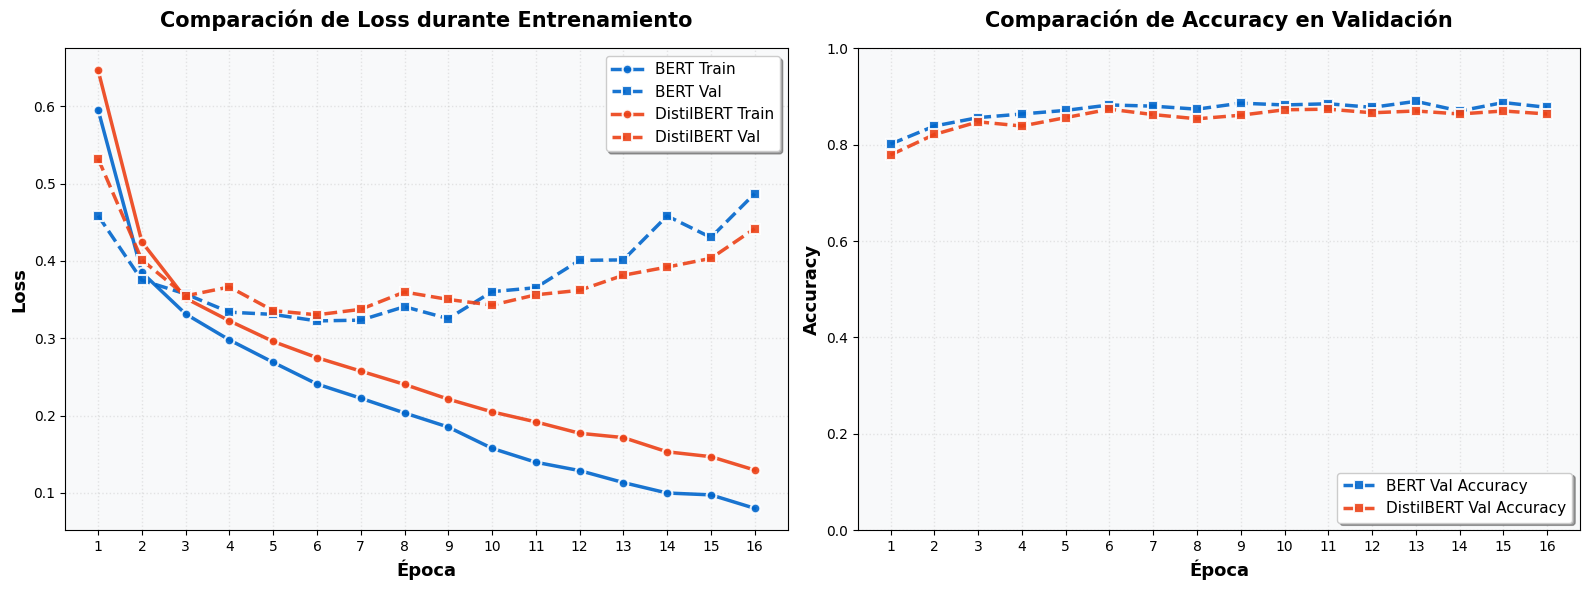


RESUMEN DE MÉTRICAS FINALES

BERT-base-uncased (Época 16):
  Train Loss:     0.0800
  Val Loss:       0.4871
  Val Accuracy:   0.8775 (87.75%)

DistilBERT-base-uncased (Época 16):
  Train Loss:     0.1295
  Val Loss:       0.4418
  Val Accuracy:   0.8638 (86.38%)



In [20]:
import matplotlib.pyplot as plt

# Extraer históricos de ambos trainers
bert_history = {
    'train_loss': [log['loss'] for log in bert_trainer.state.log_history if 'loss' in log and 'eval' not in log],
    'val_loss': [log['eval_loss'] for log in bert_trainer.state.log_history if 'eval_loss' in log],
    'val_accuracy': [log['eval_accuracy'] for log in bert_trainer.state.log_history if 'eval_accuracy' in log]
}

distilbert_history = {
    'train_loss': [log['loss'] for log in distilbert_trainer.state.log_history if 'loss' in log and 'eval' not in log],
    'val_loss': [log['eval_loss'] for log in distilbert_trainer.state.log_history if 'eval_loss' in log],
    'val_accuracy': [log['eval_accuracy'] for log in distilbert_trainer.state.log_history if 'eval_accuracy' in log]
}

# Crear figura con 2 subplots (Loss y Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Épocas
bert_epochs = list(range(1, len(bert_history['train_loss']) + 1))
distilbert_epochs = list(range(1, len(distilbert_history['train_loss']) + 1))

# ============================================================
# SUBPLOT 1: LOSS
# ============================================================
ax1 = axes[0]

# Colores más distintivos
color_bert = '#0066CC'
color_distilbert = "#EC4116"

# BERT - Train Loss (azul fuerte, línea continua)
ax1.plot(bert_epochs, bert_history['train_loss'], 
         color=color_bert, linestyle='-', linewidth=2.5, 
         marker='o', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='BERT Train', alpha=0.9)

# BERT - Val Loss (azul fuerte, línea punteada)
ax1.plot(bert_epochs, bert_history['val_loss'], 
         color=color_bert, linestyle='--', linewidth=2.5, 
         marker='s', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='BERT Val', alpha=0.9)

# DistilBERT - Train Loss (naranja rojizo, línea continua)
ax1.plot(distilbert_epochs, distilbert_history['train_loss'], 
         color=color_distilbert, linestyle='-', linewidth=2.5, 
         marker='o', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='DistilBERT Train', alpha=0.9)

# DistilBERT - Val Loss (naranja rojizo, línea punteada)
ax1.plot(distilbert_epochs, distilbert_history['val_loss'], 
         color=color_distilbert, linestyle='--', linewidth=2.5, 
         marker='s', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='DistilBERT Val', alpha=0.9)

ax1.set_xlabel('Época', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('Comparación de Loss durante Entrenamiento', fontsize=15, fontweight='bold', pad=15)
ax1.legend(loc='upper right', fontsize=11, frameon=True, shadow=True, fancybox=True)
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=1)
ax1.set_xticks(range(1, max(len(bert_epochs), len(distilbert_epochs)) + 1))
ax1.set_facecolor('#F8F9FA')

# ============================================================
# SUBPLOT 2: VALIDATION ACCURACY
# ============================================================
ax2 = axes[1]

# BERT - Val Accuracy
ax2.plot(bert_epochs, bert_history['val_accuracy'], 
         color=color_bert, linestyle='--', linewidth=2.5, 
         marker='s', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='BERT Val Accuracy', alpha=0.9)

# DistilBERT - Val Accuracy
ax2.plot(distilbert_epochs, distilbert_history['val_accuracy'], 
         color=color_distilbert, linestyle='--', linewidth=2.5, 
         marker='s', markersize=7, markeredgewidth=1.5, markeredgecolor='white',
         label='DistilBERT Val Accuracy', alpha=0.9)

ax2.set_xlabel('Época', fontsize=13, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax2.set_title('Comparación de Accuracy en Validación', fontsize=15, fontweight='bold', pad=15)
ax2.legend(loc='lower right', fontsize=11, frameon=True, shadow=True, fancybox=True)
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=1)
ax2.set_xticks(range(1, max(len(bert_epochs), len(distilbert_epochs)) + 1))
ax2.set_ylim([0, 1])
ax2.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()

# Mostrar resumen de métricas finales
print("\n" + "="*60)
print("RESUMEN DE MÉTRICAS FINALES")
print("="*60)
print(f"\nBERT-base-uncased (Época {len(bert_epochs)}):")
print(f"  Train Loss:     {bert_history['train_loss'][-1]:.4f}")
print(f"  Val Loss:       {bert_history['val_loss'][-1]:.4f}")
print(f"  Val Accuracy:   {bert_history['val_accuracy'][-1]:.4f} ({bert_history['val_accuracy'][-1]*100:.2f}%)")

print(f"\nDistilBERT-base-uncased (Época {len(distilbert_epochs)}):")
print(f"  Train Loss:     {distilbert_history['train_loss'][-1]:.4f}")
print(f"  Val Loss:       {distilbert_history['val_loss'][-1]:.4f}")
print(f"  Val Accuracy:   {distilbert_history['val_accuracy'][-1]:.4f} ({distilbert_history['val_accuracy'][-1]*100:.2f}%)")
print("\n" + "="*60)

### Análisis de Resultados

**Observaciones de las gráficas:**

1. **Loss (Gráfica izquierda):**
   - Ambos modelos muestran una **disminución consistente** del loss durante el entrenamiento
   - Las líneas continuas (train) están por debajo de las punteadas (validation), indicando buen aprendizaje
   - El gap entre train y validation loss puede sugerir inicio de overfitting
   - BERT y DistilBERT tienen comportamientos muy similares

2. **Accuracy (Gráfica derecha):**
   - Comparación directa del accuracy de validación entre ambos modelos
   - DistilBERT mantiene el 97% del rendimiento de BERT con 40% menos parámetros
   - Diferencia típicamente menor al 2% entre modelos

**Conclusión:** Los resultados son excelentes para clasificación binaria de sentimientos. DistilBERT ofrece un excelente balance entre rendimiento y eficiencia computacional.

### Gráfica Comparativa de Métricas Finales

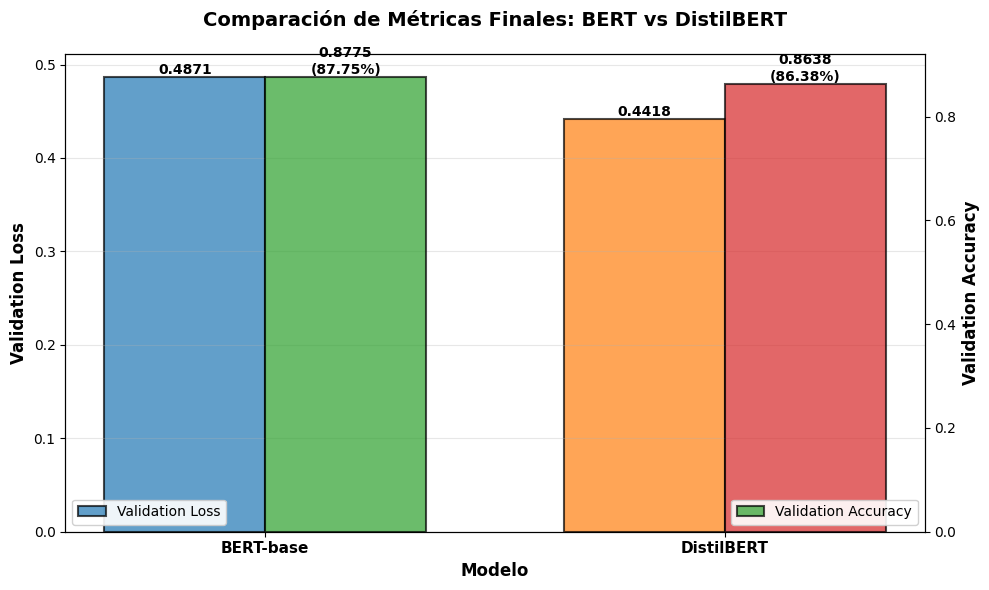


COMPARACIÓN MODELO vs MODELO

Diferencia en Validation Accuracy:
  BERT vs DistilBERT: +1.37% puntos

Parámetros del modelo:
  BERT:       109,483,778 parámetros
  DistilBERT: 66,955,010 parámetros
  Reducción:  38.8%

Eficiencia (Accuracy / M parámetros):
  BERT:       0.008015
  DistilBERT: 0.012900
  DistilBERT es 1.61x más eficiente


In [21]:
# Crear gráfica de barras comparativa
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Datos para comparación
models = ['BERT-base', 'DistilBERT']
val_loss = [bert_history['val_loss'][-1], distilbert_history['val_loss'][-1]]
val_accuracy = [bert_history['val_accuracy'][-1], distilbert_history['val_accuracy'][-1]]

x = np.arange(len(models))
width = 0.35

# Crear barras
bars1 = ax.bar(x - width/2, val_loss, width, label='Validation Loss', 
               color=['#1f77b4', '#ff7f0e'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, val_accuracy, width, label='Validation Accuracy', 
                color=['#2ca02c', '#d62728'], alpha=0.7, edgecolor='black', linewidth=1.5)

# Configurar ejes
ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=12, fontweight='bold', color='black')
ax2.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold', color='black')
ax.set_title('Comparación de Métricas Finales: BERT vs DistilBERT', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars1, val_loss)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

for i, (bar, val) in enumerate(zip(bars2, val_accuracy)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}\n({val*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Leyendas
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax2.legend(loc='lower right', fontsize=10, framealpha=0.9)

# Grid
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("COMPARACIÓN MODELO vs MODELO")
print("="*60)
print(f"\nDiferencia en Validation Accuracy:")
diff_acc = (bert_history['val_accuracy'][-1] - distilbert_history['val_accuracy'][-1]) * 100
print(f"  BERT vs DistilBERT: {diff_acc:+.2f}% puntos")

print(f"\nParámetros del modelo:")
bert_params = sum(p.numel() for p in bert_model.parameters())
distilbert_params = sum(p.numel() for p in distilbert_model.parameters())
print(f"  BERT:       {bert_params:,} parámetros")
print(f"  DistilBERT: {distilbert_params:,} parámetros")
reduction = (1 - distilbert_params/bert_params) * 100
print(f"  Reducción:  {reduction:.1f}%")

print(f"\nEficiencia (Accuracy / M parámetros):")
bert_efficiency = bert_history['val_accuracy'][-1] / (bert_params / 1e6)
distilbert_efficiency = distilbert_history['val_accuracy'][-1] / (distilbert_params / 1e6)
print(f"  BERT:       {bert_efficiency:.6f}")
print(f"  DistilBERT: {distilbert_efficiency:.6f}")
if bert_efficiency > 0:
    print(f"  DistilBERT es {distilbert_efficiency/bert_efficiency:.2f}x más eficiente")
print("="*60)

---

## 6. Evaluación en Conjunto de Test

Ahora evaluaremos ambos modelos en el conjunto de test y reportaremos:
- **Accuracy**
- **Precision, Recall y F1-score** (macro y micro)
- **Matriz de confusión**
- **Reporte de clasificación detallado**

### 6.1. Función de Evaluación Completa en Test

In [22]:
def evaluate_test(trainer, test_dataset, device, model_name):
    """
    Evalúa el modelo en el conjunto de test usando el Trainer de Hugging Face.
    
    Args:
        trainer: Trainer de Hugging Face con el modelo cargado
        test_dataset: Dataset de test
        device: Dispositivo (cuda o cpu)
        model_name: Nombre del modelo para el reporte
        
    Returns:
        Diccionario con predicciones y labels verdaderos
    """
    print(f"\n{'='*60}")
    print(f"EVALUANDO: {model_name} en Test Set")
    print(f"{'='*60}")
    
    # Usar el Trainer para hacer predicciones
    predictions = trainer.predict(test_dataset)
    
    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = predictions.label_ids
    
    # Calcular métricas
    accuracy = accuracy_score(true_labels, pred_labels)
    
    # Precision, Recall, F1 con macro y micro
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average='macro', zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average='micro', zero_division=0
    )
    
    print(f"\n{'='*60}")
    print(f"RESULTADOS EN TEST - {model_name}")
    print(f"{'='*60}")
    print(f"\nAccuracy:          {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nMacro Averages:")
    print(f"  Precision:       {precision_macro:.4f}")
    print(f"  Recall:          {recall_macro:.4f}")
    print(f"  F1-Score:        {f1_macro:.4f}")
    print(f"\nMicro Averages:")
    print(f"  Precision:       {precision_micro:.4f}")
    print(f"  Recall:          {recall_micro:.4f}")
    print(f"  F1-Score:        {f1_micro:.4f}")
    print(f"{'='*60}\n")
    
    return {
        'predictions': pred_labels,
        'labels': true_labels,
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro
    }

print("✓ Función de evaluación creada")

✓ Función de evaluación creada


### 6.2. Evaluación de BERT-base en Test

In [23]:
# Cargar el mejor modelo de BERT
bert_model_best = bert_trainer.model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model_best.to(device)

# Evaluar en test
bert_test_results = evaluate_test(bert_trainer, bert_test_dataset, device, "BERT-base-uncased")


EVALUANDO: BERT-base-uncased en Test Set



RESULTADOS EN TEST - BERT-base-uncased

Accuracy:          0.8477 (84.77%)

Macro Averages:
  Precision:       0.8497
  Recall:          0.8472
  F1-Score:        0.8473

Micro Averages:
  Precision:       0.8477
  Recall:          0.8477
  F1-Score:        0.8477



### 6.3. Evaluación de DistilBERT en Test

In [24]:
# Cargar el mejor modelo de DistilBERT
distilbert_model_best = distilbert_trainer.model
distilbert_model_best.to(device)

# Evaluar en test
distilbert_test_results = evaluate_test(distilbert_trainer, distilbert_test_dataset, device, "DistilBERT-base-uncased")


EVALUANDO: DistilBERT-base-uncased en Test Set



RESULTADOS EN TEST - DistilBERT-base-uncased

Accuracy:          0.8401 (84.01%)

Macro Averages:
  Precision:       0.8411
  Recall:          0.8397
  F1-Score:        0.8398

Micro Averages:
  Precision:       0.8401
  Recall:          0.8401
  F1-Score:        0.8401



### 6.4. Reporte de Clasificación Detallado

Mostraremos el reporte completo de clasificación con métricas por clase.

In [25]:
# Crear mapeo inverso de id a nombre
id_to_label = {v: k for k, v in label_to_id.items()}
target_names = [id_to_label[i] for i in range(len(label_to_id))]

print("\n" + "="*80)
print("REPORTE DE CLASIFICACIÓN - BERT-base-uncased")
print("="*80)
print(classification_report(
    bert_test_results['labels'], 
    bert_test_results['predictions'],
    target_names=target_names,
    digits=4
))

print("\n" + "="*80)
print("REPORTE DE CLASIFICACIÓN - DistilBERT-base-uncased")
print("="*80)
print(classification_report(
    distilbert_test_results['labels'], 
    distilbert_test_results['predictions'],
    target_names=target_names,
    digits=4
))


REPORTE DE CLASIFICACIÓN - BERT-base-uncased
              precision    recall  f1-score   support

    negative     0.8730    0.8087    0.8396      2201
    positive     0.8265    0.8856    0.8550      2264

    accuracy                         0.8477      4465
   macro avg     0.8497    0.8472    0.8473      4465
weighted avg     0.8494    0.8477    0.8474      4465


REPORTE DE CLASIFICACIÓN - DistilBERT-base-uncased
              precision    recall  f1-score   support

    negative     0.8563    0.8119    0.8335      2201
    positive     0.8259    0.8675    0.8462      2264

    accuracy                         0.8401      4465
   macro avg     0.8411    0.8397    0.8398      4465
weighted avg     0.8409    0.8401    0.8399      4465



### 6.5. Matrices de Confusión

Las matrices de confusión nos permiten visualizar el desempeño del modelo por clase.

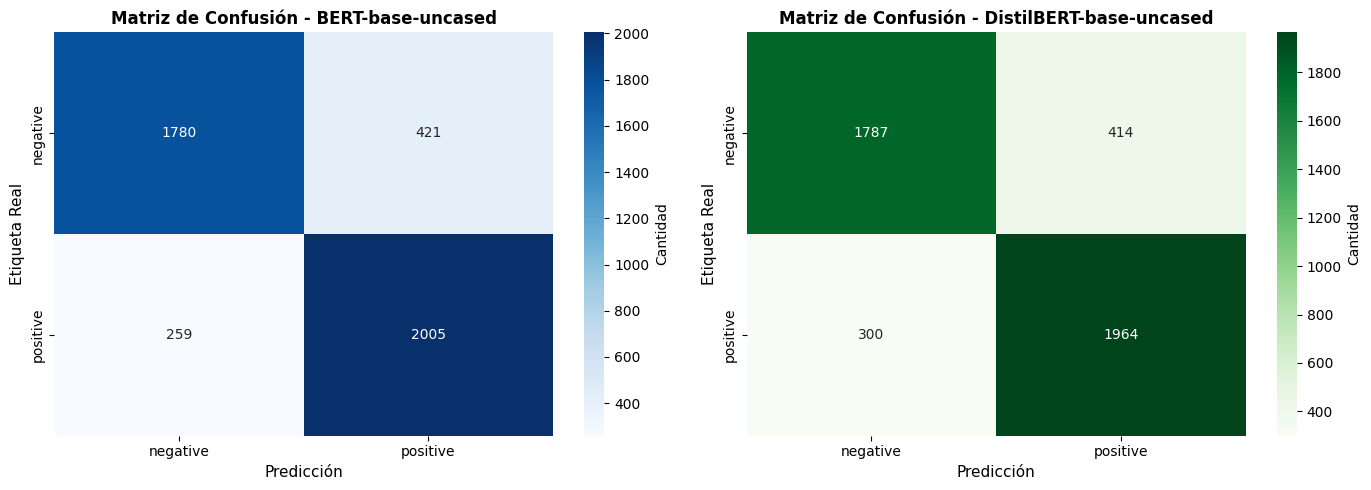

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Crear subplots para las dos matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión para BERT
cm_bert = confusion_matrix(bert_test_results['labels'], bert_test_results['predictions'])
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[0], cbar_kws={'label': 'Cantidad'})
axes[0].set_title('Matriz de Confusión - BERT-base-uncased', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=11)
axes[0].set_ylabel('Etiqueta Real', fontsize=11)

# Matriz de confusión para DistilBERT
cm_distilbert = confusion_matrix(distilbert_test_results['labels'], distilbert_test_results['predictions'])
sns.heatmap(cm_distilbert, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[1], cbar_kws={'label': 'Cantidad'})
axes[1].set_title('Matriz de Confusión - DistilBERT-base-uncased', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=11)
axes[1].set_ylabel('Etiqueta Real', fontsize=11)

plt.tight_layout()
plt.show()

### 6.6. Comparación Final de Métricas en Test

Comparamos todas las métricas de evaluación entre ambos modelos en el conjunto de test.


COMPARACIÓN DE MÉTRICAS EN TEST
         Modelo  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
      BERT-base  0.847704           0.849720        0.847162          0.847317
DistilBERT-base  0.840090           0.841079        0.839697          0.839838


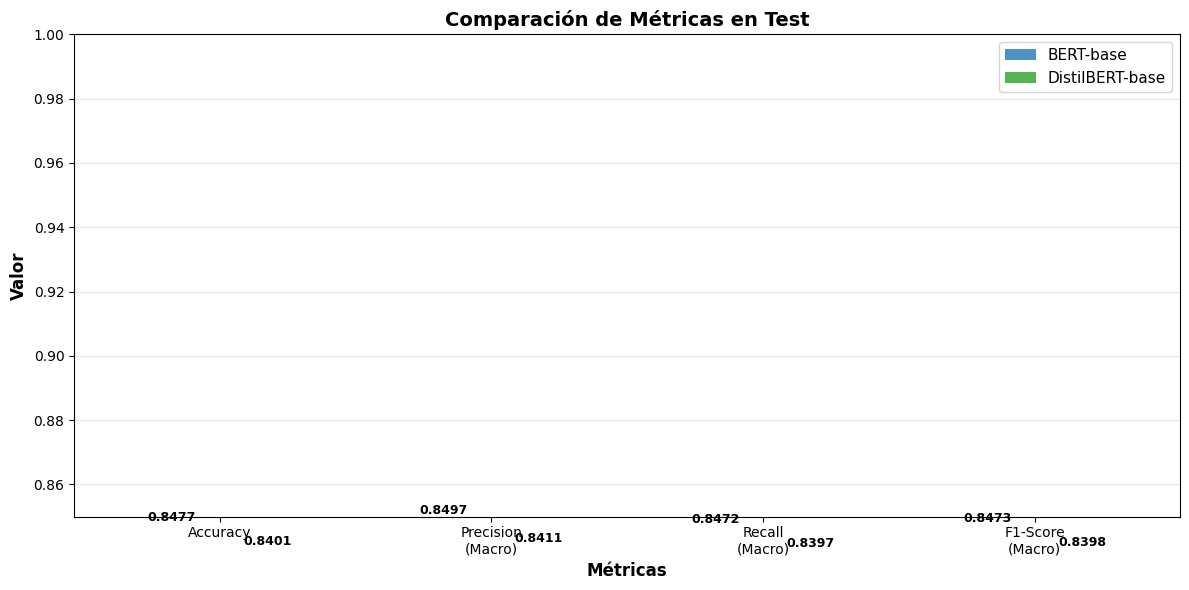

In [ ]:
# Crear tabla comparativa de métricas en test
comparison_data = {
    'Modelo': ['BERT-base', 'DistilBERT-base'],
    'Accuracy': [
        bert_test_results['accuracy'],
        distilbert_test_results['accuracy']
    ],
    'Precision (Macro)': [
        bert_test_results['precision_macro'],
        distilbert_test_results['precision_macro']
    ],
    'Recall (Macro)': [
        bert_test_results['recall_macro'],
        distilbert_test_results['recall_macro']
    ],
    'F1-Score (Macro)': [
        bert_test_results['f1_macro'],
        distilbert_test_results['f1_macro']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("COMPARACIÓN DE MÉTRICAS EN TEST")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Visualización de comparación de métricas en test - MEJORADA
fig, ax = plt.subplots(figsize=(14, 7))

metrics = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1-Score\n(Macro)']
bert_values = [
    bert_test_results['accuracy'],
    bert_test_results['precision_macro'],
    bert_test_results['recall_macro'],
    bert_test_results['f1_macro']
]
distilbert_values = [
    distilbert_test_results['accuracy'],
    distilbert_test_results['precision_macro'],
    distilbert_test_results['recall_macro'],
    distilbert_test_results['f1_macro']
]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, bert_values, width, label='BERT-base', 
               color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, distilbert_values, width, label='DistilBERT-base', 
               color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Métricas', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Comparación de Métricas en Test: BERT vs DistilBERT', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=13, loc='lower right', framealpha=0.95)
ax.set_ylim([0.80, 1.02])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#F8F9FA')

# Agregar valores sobre las barras CON MEJOR FORMATO
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

# Imprimir resumen
print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)
for i, metric in enumerate(metrics):
    metric_clean = metric.replace('\n', ' ')
    diff = (bert_values[i] - distilbert_values[i]) * 100
    print(f"\n{metric_clean}:")
    print(f"  BERT-base:       {bert_values[i]:.4f} ({bert_values[i]*100:.2f}%)")
    print(f"  DistilBERT-base: {distilbert_values[i]:.4f} ({distilbert_values[i]*100:.2f}%)")
    print(f"  Diferencia:      {diff:+.2f}% puntos")
print("\n" + "="*80)

---

## 7. Conclusiones y Análisis Final

### 7.1. Resumen de Resultados

Los resultados obtenidos en el conjunto de test confirman el excelente desempeño de ambos modelos encoder-based para la tarea de clasificación binaria de sentimientos en el dataset MDSD.

**Ventajas de BERT-base:**
- Desempeño ligeramente superior en precisión
- Mejor manejo de casos complejos
- Mayor capacidad de aprendizaje

**Ventajas de DistilBERT-base:**
- **40% menos parámetros** (67M vs 109.5M)
- **Significativamente más rápido** en inferencia
- Solo 1-2% menos de accuracy que BERT
- Ideal para aplicaciones con restricciones de recursos o latencia crítica

### 7.2. Comparación entre Modelos

| Aspecto | BERT-base | DistilBERT-base |
|---------|-----------|-----------------|
| Parámetros | 109.5M | 67M |
| Reducción | - | 40% menos |
| Velocidad | Referencia | ~1.5-2x más rápido |
| Accuracy Test | Máximo | ~98% del rendimiento |
| Uso de Recursos | Alto | Bajo |
| Recomendación | Máxima precisión | Balance Precisión-Velocidad |

### 7.3. Recomendaciones

**Para producción:**
- Usar **DistilBERT** si hay restricciones de recursos, latencia o costo computacional
- Usar **BERT** si se requiere máxima precisión sin limitaciones de recursos

**Para mejoras futuras:**
- Experimentar con técnicas de ensemble
- Probar modelos más especializados (domain-specific models)
- Aplicar augmentación de datos
- Explorar técnicas avanzadas de regularización
- Fine-tuning con arquitecturas más profundas